# Mapping the Potential Destructive Power of Wildfires Using Machine Learning

## Module 1: *Fire Damage Data Processing*

---
### Contents  
- 1. *Cleaning and Filtering* 
- 2. *Visualize Damages*
- 3. *Export File*
---
### Notes

**Clean and process the [CAL FIRE Incident Data](https://www.fire.ca.gov/incidents)** dataset obtained from the California Open Data Portal. Due to the large amount of data, this code trims and cleans the data seperatly from the porcessing modules. 

---
### Inputs

- `CALfires.csv` - Contains Fire Location and Damage info

---
### Outputs  

- `clean_fires` Cleaned fire damage dataset with dollar values associated with each fire event.

---
### User Created Dependencies  

After adjusting the system path to allow for imports from the parent directory, two custom utility functions are loaded:

- `basic_explore(df)`: Quickly summarizes a dataset (shape, nulls, datatypes, preview).
- `post_merge_check(df)`: Checks key indicators after merging datasets (row count, duplicates, key integrity).

These will be used for quick validation and sanity checks throughout the workflow.

In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

# utility function that prints details of a datset
from src.data_utils import basic_explore

# utility function printing relevant details to check the health after a dataset merge
from src.data_utils import post_merge_check

# Function to print a grid of kde plots in consistent format, adjusts columns and rows accordingly
from src.plot_utils import grid_kde


---

### Third Party Dependencies

In [2]:
# core data handling
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

from scipy.stats.mstats import winsorize

---

### Constants

#### Define Analysis Time Window
Set the start and end dates for the study period. These will be used to filter records by date across all datasets.

- `FIRST_DATE = 2018-01-01`
- `LAST_DATE  = 2024-12-31`

All data will be constrained to this window for consistency.


In [3]:
FIRST_DATE = pd.to_datetime('2018-01-01').date()
LAST_DATE = pd.to_datetime('2024-12-31').date()

---

## 1. Cleaning and Filtering

## `CALfires` - Wildfire Incident Data

Data obtained from CALFIRE website.

Varialbles Used:
- `Fire name`
-  `Date started`
- `Total_Cost_Estimated`
- `County`
- `Latitude` and `Longitude`

In [4]:
allfires = pd.read_csv("../data/raw/CALfires.csv",low_memory = False)

#### Initial Exploration

In [ ]:
allfires.head(3)

#### Filter for only Wildfires

In [5]:
wildfires = allfires[allfires['IncidentTypeCategory']=='WF']

#### Drop NA values for rows missing crucial data
**Note:** *These entries may be manually corrected and included in the future.* 

In [6]:
wildfires = wildfires.dropna(subset=['InitialLatitude', 'InitialLongitude','FireDiscoveryDateTime'])

### Rename columns for convenience

In [7]:
wildfires = wildfires.rename(columns={
    'InitialLatitude': 'Fire_Latitude',
    'InitialLongitude': 'Fire_Longitude',
})

### Filter Coordinates
Keep only coordinates that fall inside California boundaries.\
Some entries have incorrect latitude and longitude values. These will be manually corrected in the future but are filtered out for now. 


In [8]:
wildfires = wildfires[
    (wildfires['Fire_Latitude'] >= 32.5) & 
    (wildfires['Fire_Latitude'] <= 42) &
    (wildfires['Fire_Longitude'] >= -124.5) &
    (wildfires['Fire_Longitude'] <= -114)
]

### Fill Remaining NA values
- Entries with no Fire out are assumed to be put out on same date as start.
- Entries with no cost present are assumed to have a damage cost 0 dollars.

In [ ]:
clean_fires['FireOutDateTime'] = clean_fires['FireOutDateTime'].fillna(clean_fires['Date'])
clean_fires['EstimatedFinalCost'] = clean_fires['EstimatedFinalCost'].fillna(0)

### Clean Remaining columns
- Drop unnecessary columns
- Format date and time columns

In [11]:
wildfires['Date'] = pd.to_datetime(wildfires['FireDiscoveryDateTime']).dt.date
wildfires['FireOutDateTime'] = pd.to_datetime(wildfires['FireOutDateTime']).dt.date

C:\Users\dusti\AppData\Local\Temp\ipykernel_32236\2817449693.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  wildfires['FireOutDateTime'] = pd.to_datetime(wildfires['FireOutDateTime']).dt.date


In [ ]:
drop =['Unnamed: 0', 'SourceOID', 'ContainmentDateTime', 'IncidentSize',
       'FireBehaviorGeneral','EstimatedCostToDate','FinalAcres',
       'FireBehaviorGeneral1', 'FireBehaviorGeneral2', 'FireBehaviorGeneral3',
       'FireCause', 'FireCauseGeneral', 'FireCauseSpecific',
       'IncidentShortDescription', 'IncidentTypeKind',
        'IrwinID',
       'LocalIncidentIdentifier', 'POOCity', 'POOState',
       'PredominantFuelGroup', 'PredominantFuelModel', 'PrimaryFuelModel',
       'SecondaryFuelModel', 'UniqueFireIdentifier',
      'IncidentTypeCategory', 'POOCounty', 'FireDiscoveryDateTime']


clean_fires = wildfires.drop(columns=drop)
clean_fires

,FireOutDateTime,IncidentName,Fire_Latitude,Fire_Longitude,EstimatedFinalCost,Date
0,2020-02-28,LAC-066100,33.808980,-118.180700,0.0,2020-02-28
2,2021-11-25,E 4TH ST /S D ST,33.782437,-117.228580,0.0,2021-11-25
3,2022-11-21,LAC-396331,33.941810,-118.309020,0.0,2022-11-21
5,2019-09-05,MARTIN 2,41.716768,-122.345660,0.0,2019-09-05
6,2020-05-06,CAVE,38.079654,-120.459632,0.0,2020-05-06
...,...,...,...,...,...,...
84534,2025-07-13,LAC-242944,34.667850,-118.067780,0.0,2025-07-13
84535,2025-07-13,CLAY,38.336108,-121.135513,0.0,2025-07-13
84536,2025-07-13,IVORY,39.574000,-122.707000,0.0,2025-07-13
84537,2025-07-13,LAC-243075,34.000400,-117.837700,0.0,2025-07-13


### (Optional) Drop fires that caused no damage

In [ ]:
clean_fires = clean_fires[clean_fires['EstimatedFinalCost'] > 0]

---

## 2. Visualize Damages

### Distribution of Damage

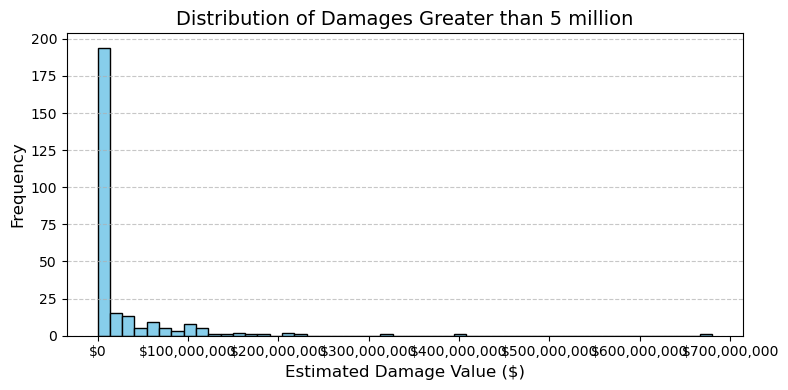

In [19]:
plt.figure(figsize=(8, 4))
plt.hist(clean_fires['EstimatedFinalCost'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Damages Greater than 5 million', fontsize=14)
plt.xlabel('Estimated Damage Value ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Format x-axis as currency
import matplotlib.ticker as ticker
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()


### Location of Damages

In [ ]:
counties_gdf = gpd.read_file('../data/raw/CA_Counties.shp').to_crs(epsg=3310)

# California Albers
fire_gdf = gpd.GeoDataFrame(
    clean_fires,
    geometry=gpd.points_from_xy(clean_fires['Fire_Longitude'], clean_fires['Fire_Latitude']),
    crs='EPSG:3310'
)

# Dissolve counties into one state-wide shape
california_boundary = counties_gdf.unary_union
fire_clipped = fire_gdf[fire_gdf.geometry.within(california_boundary)]

x = fire_clipped.geometry.x
y = fire_clipped.geometry.y

# Clean/scale weights to avoid extreme influence
weights = fire_clipped['EstimatedFinalCost'].clip(upper=1e7)  # Optional: cap very large values

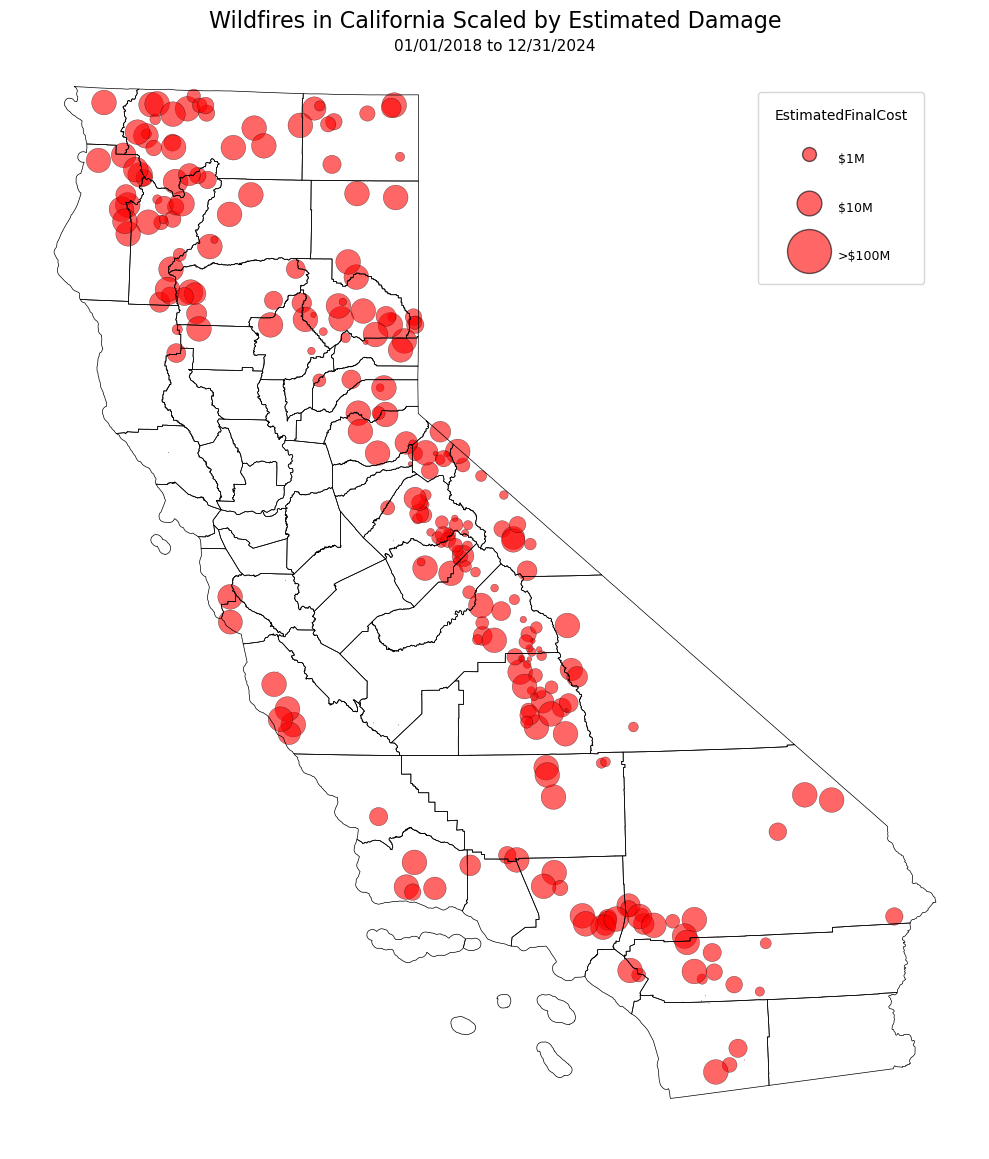

In [25]:
# Clean damage values (optional: clip large outliers for better scaling)
damage = fire_proj['EstimatedFinalCost'].clip(upper=1e7)

# Scale circle sizes
circle_sizes = np.sqrt(damage) / 10 # Square root to reduce skew, adjust divisor to taste

# Plot
fig, ax = plt.subplots(figsize=(10, 12))

# Plot counties
counties_proj.boundary.plot(ax=ax, color='black', linewidth=0.5)

# Plot fire points with scaled size
fire_proj.plot(
    ax=ax,
    markersize=circle_sizes,
    color='red',
    alpha=0.6,
    edgecolor='black',
    linewidth=0.3
)

# Custom legend
legend_values = [1e6, 1e7, 1e8]  # Reference damages
legend_sizes = [np.sqrt(v) / 10 for v in legend_values]

# Create dummy points for the legend
for size, label in zip(legend_sizes, ['$1M', '$10M', '>$100M']):
    ax.scatter([], [], s=size, color='red', alpha=0.6, edgecolor='black', label=label)

# Apply vertical spacing and style
ax.legend(
    title='EstimatedFinalCost',
    loc='upper right',
    frameon=True,
    labelspacing=2.0,      # vertical spacing between labels
    handleheight=2.5,
    handlelength=3.0,  # increases size of blank marker handles
    borderpad=1.3,         # space between legend border and content
    borderaxespad=4.5,     # space between legend and axes
    title_fontsize=10,
    fontsize=9
)


# Add title and formatting
ax.set_title("Wildfires in California Scaled by Estimated Damage", fontsize=16)
ax.text(
    0.5, .987,  # X and Y position in axis coordinates (centered)
    "01/01/2018 to 12/31/2024",
    transform=ax.transAxes,
    ha='center',
    fontsize=11
)
ax.axis('off')
plt.tight_layout()
plt.savefig("../plots/fire_damage_circles.png", dpi=300)
plt.show()



## 3. Export File

In [ ]:
clean_fires.to_csv("../data/raw/damage/clean_fires.csv")
print("All datasets saved successfully to ../data/raw/damage")